***Exploration of solar and wind capacity factor data by state, and correlations between states***

Using preproduced daily data masked to renewable energy zones by state.

Produces:

- Kernel density estimate/scatter plots for solar/wind capacity factor for each state, all year and winter only
- Conditional probability plots across states for solar lulls, all year and winter only
- Conditional probability plots across states for wind lulls, all year and winter only
- Conditional probability plots across states for combined (solar+wind) lulls, all year and winter only

In [23]:
# load libraries
import xarray as xr
#from dask.distributed import Client
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

# define data paths
solar_cf_path = "/home/561/jl1950/GC26-combined-solar-wind/data/processed/daily-state-cf/solar_daily-state-cf.nc"
wind_cf_path = "/home/561/jl1950/GC26-combined-solar-wind/data/processed/daily-state-cf/wind_daily-state-cf.nc"

# load data
ds_solar_cf = xr.load_dataset(solar_cf_path, chunks='auto')
ds_wind_cf = xr.load_dataset(wind_cf_path, chunks='auto')

# calculate 10p on all data then filter to winter only
ds_solar_10p_bystate = ds_solar_cf.quantile(0.10, dim="time")
ds_wind_10p_bystate = ds_wind_cf.quantile(0.10, dim="time")

print(ds_solar_10p_bystate)
print(ds_wind_10p_bystate)

# filter to winter only
ds_solar_cf_winter = ds_solar_cf.sel(time=ds_solar_cf.time.dt.month.isin([6, 7, 8]))
ds_wind_cf_winter = ds_wind_cf.sel(time=ds_wind_cf.time.dt.month.isin([6, 7, 8]))

print("---ds_solar_cf_winter---")
print(ds_solar_cf_winter)
print("---ds_wind_cf_winter---")
print(ds_wind_cf_winter)

<xarray.Dataset> Size: 48B
Dimensions:   ()
Coordinates:
    quantile  float64 8B 0.1
Data variables:
    Q         float64 8B 0.1476
    N         float64 8B 0.1121
    V         float64 8B 0.08439
    S         float64 8B 0.1039
    T         float64 8B 0.06908
<xarray.Dataset> Size: 48B
Dimensions:   ()
Coordinates:
    quantile  float64 8B 0.1
Data variables:
    Q         float64 8B 0.03008
    N         float64 8B 0.03449
    V         float64 8B 0.04026
    S         float64 8B 0.04425
    T         float64 8B 0.03106
---ds_solar_cf_winter---
<xarray.Dataset> Size: 116kB
Dimensions:      (time: 4140)
Coordinates:
  * time         (time) datetime64[ns] 33kB 1979-06-01 1979-06-02 ... 2023-08-31
    spatial_ref  int64 8B 0
Data variables:
    Q            (time) float32 17kB 0.1824 0.1531 0.1609 ... 0.2178 0.2286
    N            (time) float32 17kB 0.1268 0.1273 0.1323 ... 0.1722 0.1833
    V            (time) float32 17kB 0.1063 0.1193 0.1153 ... 0.1246 0.1075
    S            (t

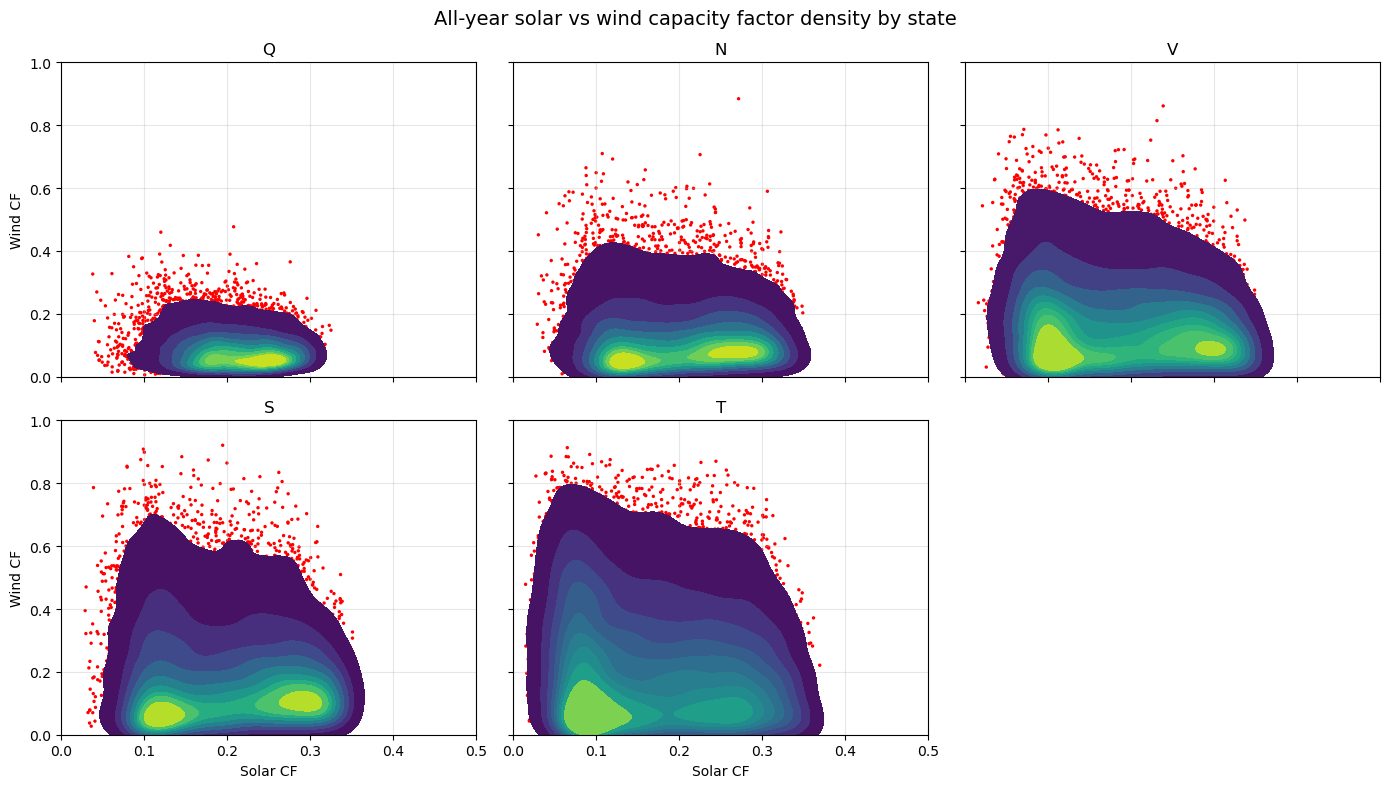

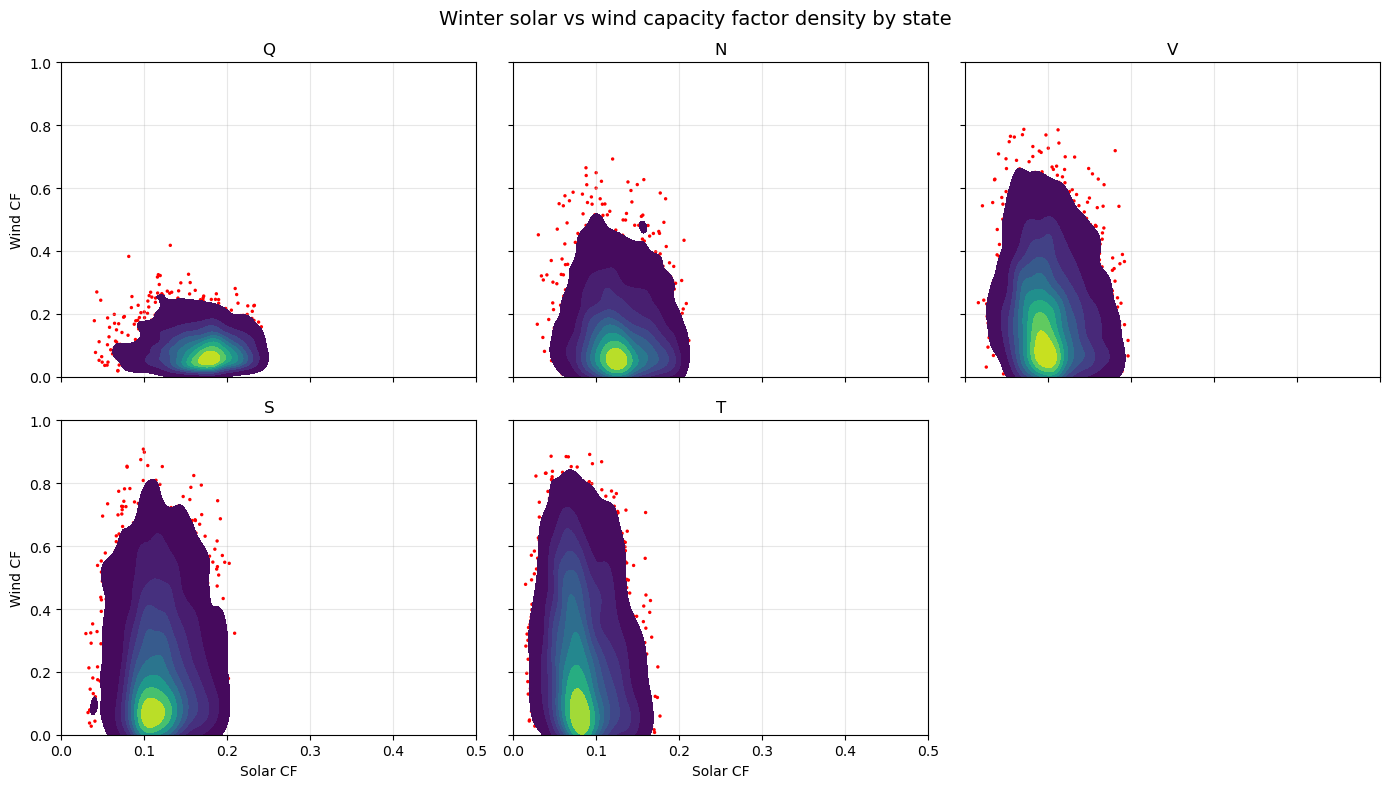

In [12]:
# ---make kde and scatter plots by state (all data, and winter only)---

# with all data
ds_solar = ds_solar_cf
ds_wind  = ds_wind_cf

ds_solar_aligned, ds_wind_aligned = xr.align(ds_solar, ds_wind, join="inner")

states = ["Q", "N", "V", "S", "T"]

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, state in zip(axes, states):
    x = ds_solar_aligned[state].values
    y = ds_wind_aligned[state].values

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # Points underneath
    ax.scatter(
        x,
        y,
        s=6,
        alpha=1,
        edgecolors="none",
        zorder=1,
        color="red"
    )

    # KDE on top
    sns.kdeplot(
        x=x,
        y=y,
        fill=True,
        levels=10,
        thresh=0.03,
        alpha=1,
        ax=ax,
        zorder=2,
        cmap="viridis"
    )

    ax.set_title(state)
    ax.set_xlabel("Solar CF")
    ax.set_ylabel("Wind CF")
    ax.grid(True, alpha=0.3, zorder=0)

# Remove unused sixth panel
axes[-1].axis("off")

fig.suptitle(
    "All-year solar vs wind capacity factor density by state",
    fontsize=14
)

for ax in axes[:-1]:
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1.0)

plt.tight_layout()

save_name = "solarcf_vs_windcf_bystate_allyear.png"
plt.savefig(f"/home/561/jl1950/GC26-combined-solar-wind/analysis/jonathan_sandbox/{save_name}", dpi=300, bbox_inches="tight")

plt.show()



# and now by state (winter only)
ds_solar = ds_solar_cf_winter
ds_wind  = ds_wind_cf_winter

ds_solar_aligned, ds_wind_aligned = xr.align(ds_solar, ds_wind, join="inner")

states = ["Q", "N", "V", "S", "T"]

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, state in zip(axes, states):
    x = ds_solar_aligned[state].values
    y = ds_wind_aligned[state].values

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # Points underneath
    ax.scatter(
        x,
        y,
        s=6,
        alpha=1,
        edgecolors="none",
        zorder=1,
        color="red"
    )

    # KDE on top
    sns.kdeplot(
        x=x,
        y=y,
        fill=True,
        levels=10,
        thresh=0.03,
        alpha=1,
        ax=ax,
        zorder=2,
        cmap="viridis"
    )

    ax.set_title(state)
    ax.set_xlabel("Solar CF")
    ax.set_ylabel("Wind CF")
    ax.grid(True, alpha=0.3, zorder=0)

# Remove unused sixth panel
axes[-1].axis("off")

fig.suptitle(
    "Winter solar vs wind capacity factor density by state",
    fontsize=14
)

for ax in axes[:-1]:
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1.0)

plt.tight_layout()

save_name = "solarcf_vs_windcf_bystate_winter.png"
plt.savefig(f"/home/561/jl1950/GC26-combined-solar-wind/analysis/jonathan_sandbox/{save_name}", dpi=300, bbox_inches="tight")


plt.show()

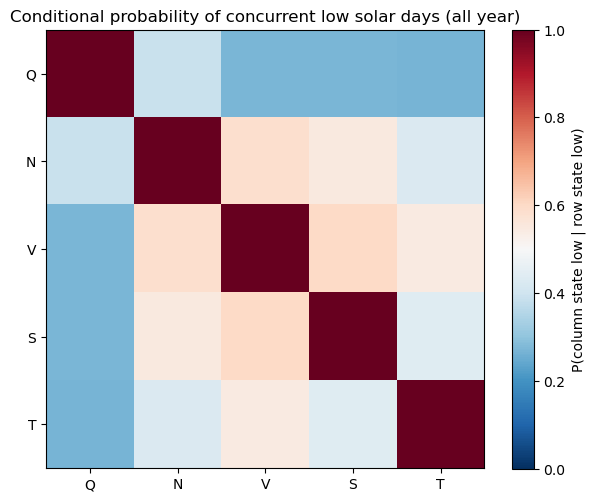

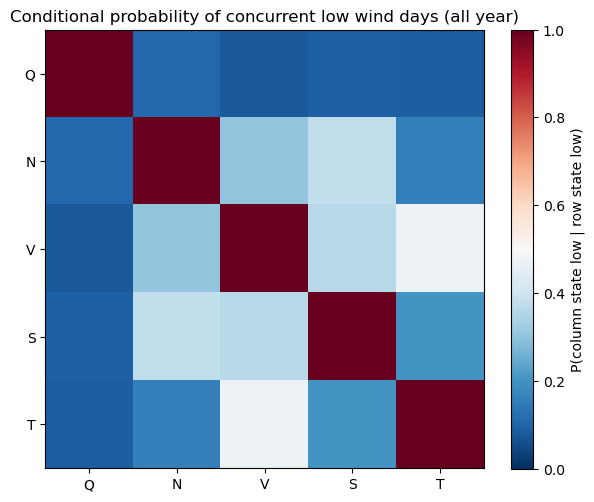

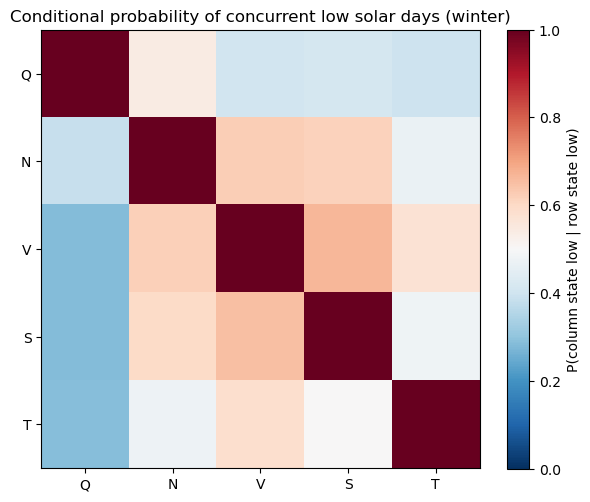

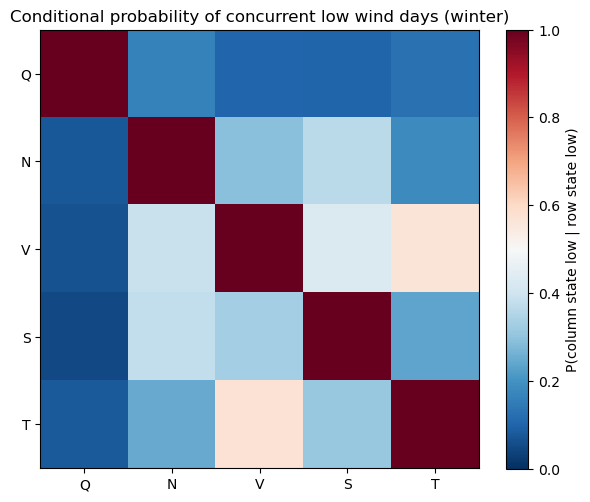

In [13]:
#---plot probability of solar lulls across multiple states---

# function to transform inputs for plotting
def _threshold_to_series(threshold, states):
    """
    Convert a threshold object into a pandas Series indexed by state.
    Handles:
    - xarray Dataset with one scalar variable per state
    - pandas Series
    - pandas DataFrame
    - scalar
    """

    if threshold is None:
        return None

    # xarray Dataset: one scalar variable per state
    if isinstance(threshold, xr.Dataset):
        values = {}

        for state in states:
            if state not in threshold:
                raise KeyError(f"{state} not found in threshold dataset")

            da = threshold[state].squeeze()

            if da.size != 1:
                raise ValueError(
                    f"Threshold for {state} is not scalar after squeeze. "
                    f"Shape is {da.shape}. Check remaining dimensions."
                )

            values[state] = float(da.values)

        return pd.Series(values, index=states)

    # xarray DataArray
    if isinstance(threshold, xr.DataArray):
        threshold = threshold.squeeze()

        if threshold.size == len(states):
            return pd.Series(threshold.values, index=states)

        if threshold.size == 1:
            return pd.Series(float(threshold.values), index=states)

        raise ValueError(
            f"Cannot convert threshold DataArray with shape {threshold.shape} "
            "to one threshold per state."
        )

    # pandas DataFrame
    if isinstance(threshold, pd.DataFrame):
        if len(threshold) == 1:
            return threshold[states].iloc[0].reindex(states)

        raise ValueError(
            "Threshold DataFrame has more than one row. "
            "Expected one threshold value per state."
        )

    # pandas Series
    if isinstance(threshold, pd.Series):
        return threshold.reindex(states)

    # scalar fallback
    return pd.Series(float(threshold), index=states)

# function to make the plot
def plot_conditional_low_probability(
    ds,
    states,
    threshold=None,
    q=0.10,
    title=None,
    save_name=None,
    save_dir="/home/561/jl1950/GC26-combined-solar-wind/analysis/jonathan_sandbox",
    cmap="RdBu_r",
):
    """
    Plot P(column state low | row state low) across states.

    If threshold is provided, it is used as the low-day threshold.
    Otherwise, the q-th quantile is calculated from ds.
    """

    # Convert selected states to dataframe
    df = ds[states].to_dataframe()[states]

    # Define low-day threshold
    if threshold is None:
        threshold = df.quantile(q)
    else:
        threshold = _threshold_to_series(threshold, states)

    # Define low days independently for each state
    low = df.lt(threshold, axis="columns")

    # Conditional probability:
    # rows = conditioning state, columns = concurrent low state
    low_prob = pd.DataFrame(index=states, columns=states, dtype=float)

    for row_state in states:
        low_prob.loc[row_state] = low.loc[low[row_state]].mean()

    # Plot
    plt.figure(figsize=(6, 5))
    plt.imshow(low_prob, vmin=0, vmax=1, cmap=cmap)

    plt.xticks(range(len(states)), states)
    plt.yticks(range(len(states)), states)
    plt.colorbar(label="P(column state low | row state low)")

    if title is not None:
        plt.title(title)

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(
            f"{save_dir}/{save_name}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return low_prob


# make plots
low_prob_solar_allyear = plot_conditional_low_probability(
    ds=ds_solar_cf,
    states=states,
    threshold=ds_solar_10p_bystate,
    title="Conditional probability of concurrent low solar days (all year)",
    save_name="lowsolarp10_probability_across_states_allyear.png"
)

low_prob_wind_allyear = plot_conditional_low_probability(
    ds=ds_wind_cf,
    states=states,
    threshold=ds_wind_10p_bystate,
    title="Conditional probability of concurrent low wind days (all year)",
    save_name="lowwindp10_probability_across_states_allyear.png"
)

low_prob_solar_winter = plot_conditional_low_probability(
    ds=ds_solar_cf_winter,
    states=states,
    threshold=ds_solar_10p_bystate,
    title="Conditional probability of concurrent low solar days (winter)",
    save_name="lowsolarp10_probability_across_states_winter.png"
)

low_prob_wind_winter = plot_conditional_low_probability(
    ds=ds_wind_cf_winter,
    states=states,
    threshold=ds_wind_10p_bystate,
    title="Conditional probability of concurrent low wind days (winter)",
    save_name="lowwindp10_probability_across_states_winter.png"
)

In [17]:
# --- produce compound low dataset---
states = ["Q", "N", "V", "S", "T"]

# Keep only state variables
solar = ds_solar_cf[states]
wind = ds_wind_cf[states]

# Calculate state-specific 10th percentiles
solar_p10 = solar.quantile(0.10, dim="time")
wind_p10 = wind.quantile(0.10, dim="time")

# Boolean masks: True where each resource is below its own state-specific 10th percentile
solar_low = solar < solar_p10
wind_low = wind < wind_p10

# True where BOTH solar and wind are low in the same state on the same day
ds_compound_low_mask = solar_low & wind_low

# and produce masked dataset of actual values where both solar and wind <= p10
ds_combined_low = xr.Dataset()

for s in states:
    mask = ds_compound_low_mask[s]

    ds_combined_low[f"solar_{s}"] = solar[s].where(mask)
    ds_combined_low[f"wind_{s}"] = wind[s].where(mask)

print(ds_combined_low)

# filter to winter only
ds_combined_low_winter = ds_combined_low.sel(time=ds_combined_low.time.dt.month.isin([6, 7, 8]))
print(ds_combined_low_winter)

<xarray.Dataset> Size: 789kB
Dimensions:      (time: 16436)
Coordinates:
  * time         (time) datetime64[ns] 131kB 1979-01-01 ... 2023-12-31
    spatial_ref  int64 8B 0
    quantile     float64 8B 0.1
Data variables:
    solar_Q      (time) float32 66kB nan nan nan nan nan ... nan nan nan nan nan
    wind_Q       (time) float32 66kB nan nan nan nan nan ... nan nan nan nan nan
    solar_N      (time) float32 66kB nan nan nan nan nan ... nan nan nan nan nan
    wind_N       (time) float32 66kB nan nan nan nan nan ... nan nan nan nan nan
    solar_V      (time) float32 66kB nan nan nan nan nan ... nan nan nan nan nan
    wind_V       (time) float32 66kB nan nan nan nan nan ... nan nan nan nan nan
    solar_S      (time) float32 66kB nan nan nan nan nan ... nan nan nan nan nan
    wind_S       (time) float32 66kB nan nan nan nan nan ... nan nan nan nan nan
    solar_T      (time) float32 66kB nan nan nan nan nan ... nan nan nan nan nan
    wind_T       (time) float32 66kB nan nan nan na

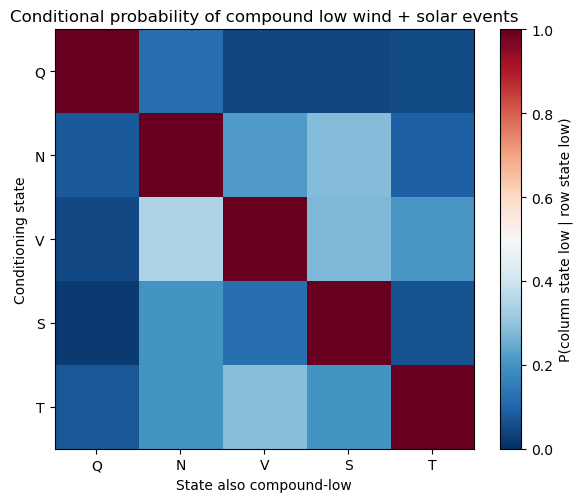

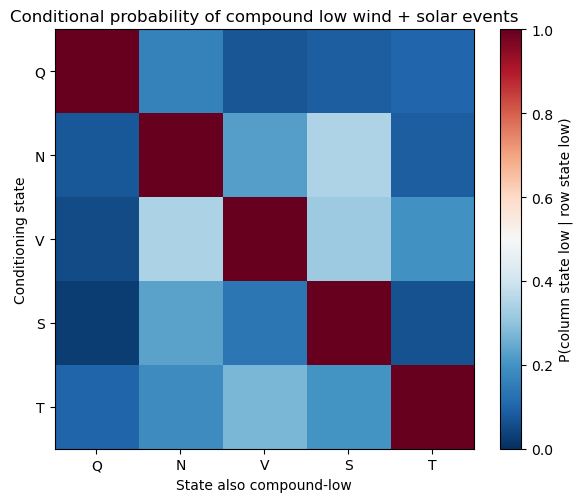

In [18]:
# calculate probabilities
def conditional_probability_from_events(event_df):
    """
    event_df: DataFrame with rows = time, columns = states, values = True/False
    Returns P(column state event | row state event)
    """

    event = event_df.astype(bool).astype(int)

    joint_counts = event.T @ event
    event_counts = event.sum(axis=0)

    cond_prob = joint_counts.div(event_counts.replace(0, np.nan), axis=0)

    return cond_prob

# plot probabilities for each state vs state
def plot_conditional_probability_matrix(
    cond_prob,
    title,
    save_name=None,
    save_dir="/home/561/jl1950/GC26-combined-solar-wind/analysis/jonathan_sandbox",
    xlabel="Column state",
    ylabel="Conditioning state",
    colorbar_label="P(column state low | row state low)",
    cmap="RdBu_r",
    annotate=False,
):
    states = cond_prob.index.tolist()

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(cond_prob.values, vmin=0, vmax=1, cmap=cmap)

    ax.set_xticks(np.arange(len(states)))
    ax.set_yticks(np.arange(len(states)))
    ax.set_xticklabels(states)
    ax.set_yticklabels(states)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    if annotate:
        for r in range(len(states)):
            for c in range(len(states)):
                ax.text(
                    c, r,
                    f"{cond_prob.iloc[r, c]:.2f}",
                    ha="center",
                    va="center"
                )

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(
            f"{save_dir}/{save_name}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# ---------------------------------------------------------------------
# Compound low solar + wind conditional probability across states
# ---------------------------------------------------------------------

# for all year data
compound_event_df = pd.DataFrame({
    s: ds_combined_low[f"solar_{s}"].notnull().values
    for s in states
}, index=ds_combined_low.time.values)

cond_prob_compound = conditional_probability_from_events(compound_event_df)

plot_conditional_probability_matrix(
    cond_prob=cond_prob_compound,
    title="Conditional probability of compound low wind + solar events",
    xlabel="State also compound-low",
    ylabel="Conditioning state",
    save_name="lowbothsolarwind10_probability_across_states_alldata.png",
    annotate=False,
)

# for winter data only
compound_event_df = pd.DataFrame({
    s: ds_combined_low_winter[f"solar_{s}"].notnull().values
    for s in states
}, index=ds_combined_low_winter.time.values)

cond_prob_compound = conditional_probability_from_events(compound_event_df)

plot_conditional_probability_matrix(
    cond_prob=cond_prob_compound,
    title="Conditional probability of compound low wind + solar events",
    xlabel="State also compound-low",
    ylabel="Conditioning state",
    save_name="lowbothsolarwind10_probability_across_states_winter.png",
    annotate=False,
)